# **Diamond Price Predictor** | Full ML Pipeline

**Dataset:** Diamonds (from Kaggle)  https://www.kaggle.com/datasets/ronil8/diamond-price-prediction-dataset

### Install the dependencies

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm joblib


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Step 1: Import Libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
import os

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor 
from lightgbm import LGBMRegressor

In [3]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

print('All libraries imported correctly!')

All libraries imported correctly!


In [4]:
data = pd.read_csv('Diamond Price Prediction.csv')

### Step 2: Load the dataset

In [5]:
print(f'Dataset shape:  {data.shape}')
print(f'Rows: {data.shape[0]} | Columns: {data.shape[1]}')
data.head(10)

Dataset shape:  (53940, 10)
Rows: 53940 | Columns: 10


,Carat(Weight of Daimond),Cut(Quality),Color,Clarity,Depth,Table,Price(in US dollars),X(length),Y(width),Z(Depth)
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


### **Step 3:** Exploratory Data Analysis (EDA)

In [6]:
print('Dataset Info: ')
data.info()

Dataset Info: 
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Carat(Weight of Daimond)  53940 non-null  float64
 1   Cut(Quality)              53940 non-null  str    
 2   Color                     53940 non-null  str    
 3   Clarity                   53940 non-null  str    
 4   Depth                     53940 non-null  float64
 5   Table                     53940 non-null  float64
 6   Price(in US dollars)      53940 non-null  int64  
 7   X(length)                 53940 non-null  float64
 8   Y(width)                  53940 non-null  float64
 9   Z(Depth)                  53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


In [7]:
print('Missing Values: ')
data.isnull().sum()

Missing Values: 


Carat(Weight of Daimond)    0
Cut(Quality)                0
Color                       0
Clarity                     0
Depth                       0
Table                       0
Price(in US dollars)        0
X(length)                   0
Y(width)                    0
Z(Depth)                    0
dtype: int64

In [8]:
print('Basic Statistics: ')
data.describe().round(2)

Basic Statistics: 


,Carat(Weight of Daimond),Depth,Table,Price(in US dollars),X(length),Y(width),Z(Depth)
count,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00
mean,0.80,61.75,57.46,3932.80,5.73,5.73,3.54
std,0.47,1.43,2.23,3989.44,1.12,1.14,0.71
min,0.20,43.00,43.00,326.00,0.00,0.00,0.00
25%,0.40,61.00,56.00,950.00,4.71,4.72,2.91
50%,0.70,61.80,57.00,2401.00,5.70,5.71,3.53
75%,1.04,62.50,59.00,5324.25,6.54,6.54,4.04
max,5.01,79.00,95.00,18823.00,10.74,58.90,31.80


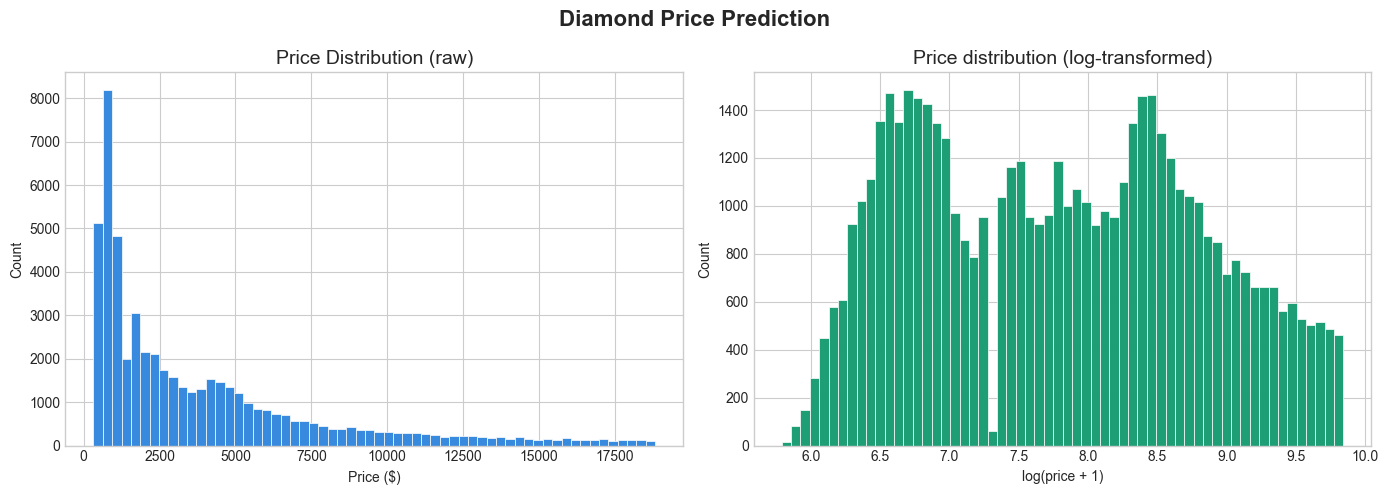

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data['Price(in US dollars)'], bins=60, color='#378ADD', edgecolor='white', linewidth=0.5)
axes[0].set_title('Price Distribution (raw)', fontsize=14)
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')
axes[1].hist(np.log1p(data['Price(in US dollars)']), bins=60, color='#1D9E75', edgecolor='white', linewidth=0.5)
axes[1].set_title('Price distribution (log-transformed)', fontsize=14)
axes[1].set_xlabel('log(price + 1)')
axes[1].set_ylabel('Count')

plt.suptitle('Diamond Price Prediction', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

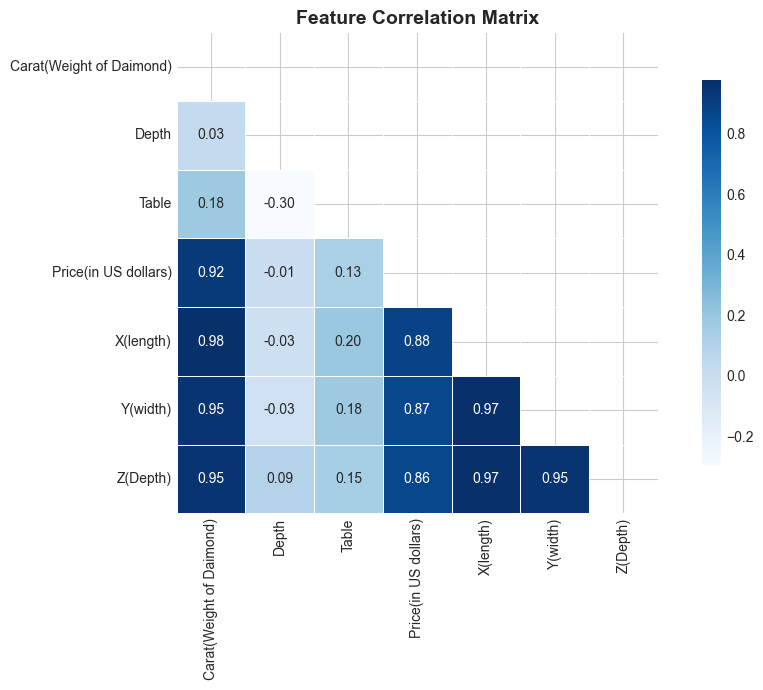

In [10]:
plt.figure(figsize=(10,7))
numeric_cols = data.select_dtypes(include='number').columns
corr = data[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5, square=True, cbar_kws={'shrink':0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

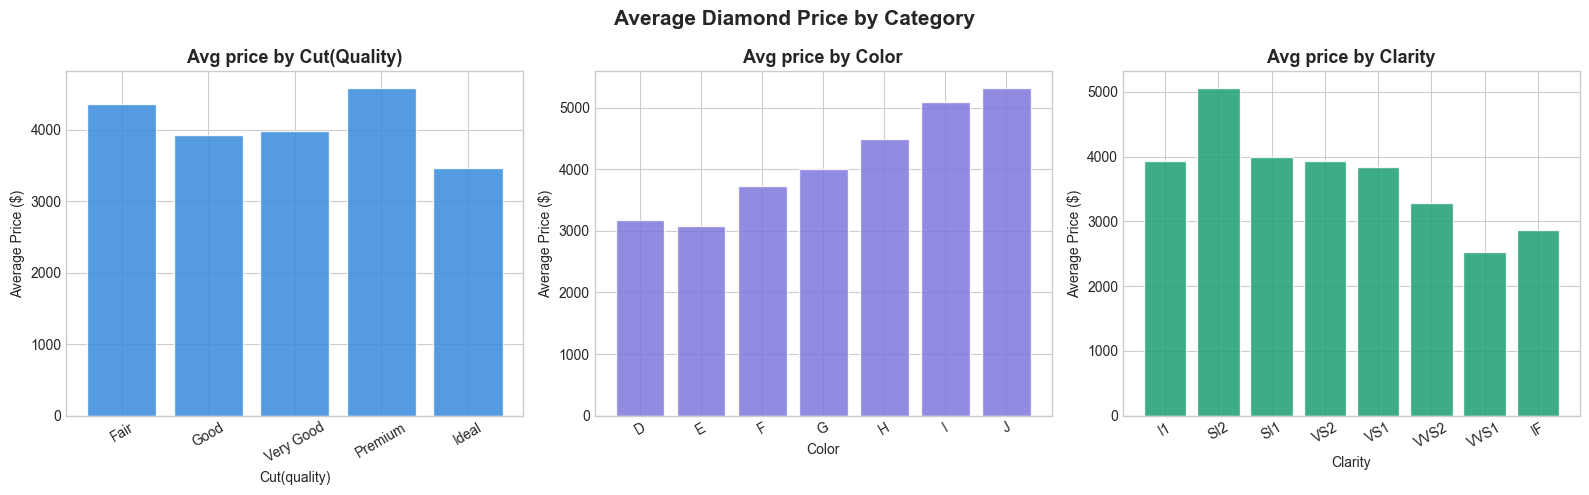

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

for ax, col, order, color in zip(
    axes, 
    ['Cut(Quality)', 'Color', 'Clarity'], 
    [cut_order, color_order, clarity_order],
    ['#378ADD', '#7F77DD', '#1D9E75']
):
    means = data.groupby(col)['Price(in US dollars)'].mean().reindex(order)
    ax.bar(means.index, means.values, color=color, alpha = 0.85, edgecolor='white')
    ax.set_title(f'Avg price by {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Average Price ($)')
    ax.tick_params(axis='x', rotation=30)


plt.suptitle('Average Diamond Price by Category', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
print(f'Orginial Shape: {data.shape}')

Orginial Shape: (53940, 10)


#### **Step 4:** Check the data to be clean

In [17]:
print('Missing Values: ')
data.isnull().sum()

Missing Values: 


Carat(Weight of Daimond)    0
Cut(Quality)                0
Color                       0
Clarity                     0
Depth                       0
Table                       0
Price(in US dollars)        0
X(length)                   0
Y(width)                    0
Z(Depth)                    0
dtype: int64

In [23]:
data_clean = data[(data['X(length)'] > 0) & (data['Y(width)'] > 0) & (data['Z(Depth)'] > 0)].copy()

data_clean = data_clean[data_clean['Price(in US dollars)'] > 0]

print(f'After cleaning: {data_clean.shape}')
print(f'Removed {data.shape[0] - data_clean.shape[0]} rows ({(data.shape[0] - data_clean.shape[0])/data.shape[0]*100:.2f}%)')

After cleaning: (53920, 10)
Removed 20 rows (0.04%)


### **Step 5:** Feature Engineering & Encoding

In [24]:
data_copy = data.copy()

data_copy['volume'] = data_copy['X(length)'] * data_copy['Y(width)'] * data_copy['Z(Depth)']

data_copy['log_carat'] = np.log1p(data_copy['Carat(Weight of Daimond)'])
data_copy['log_volume'] = np.log1p(data_copy['volume'])

data_copy['depth_ratio'] = data_copy['Z(Depth)'] / ((data_copy['X(length)'] + data_copy['Y(width)']) / 2 + 1e-9)

print('Engineered features add: volumn column, log_carat, log_volume, depth_ratio')

Engineered features add: volumn column, log_carat, log_volume, depth_ratio


##### Ordinal Encoding

In [25]:
Enc_cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
Enc_color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
Enc_clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']


actual_cut_order = [v for v in Enc_cut_order if v in data_copy['Cut(Quality)'].values]
actual_color_order = [v for v in Enc_color_order if v in data_copy['Color'].values]
actual_clarity_order = [v for v in Enc_clarity_order if v in data_copy['Clarity'].values]


print(f'Cut values found: {actual_cut_order}')
print(f'Color values found: {actual_color_order}')
print(f'Clarity values found: {actual_clarity_order}')

Cut values found: ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
Color values found: ['J', 'I', 'H', 'G', 'F', 'E', 'D']
Clarity values found: ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']


In [29]:
enc = OrdinalEncoder(
    categories=[actual_cut_order, actual_color_order, actual_clarity_order],
    handle_unknown='use_encoded_value', 
    unknown_value=-1
)

data_copy[['cut_enc', 'color_enc', 'clarity_enc']] = enc.fit_transform(
    data_copy[['Cut(Quality)', 'Color', 'Clarity']]
)

os.makedirs('../model', exist_ok=True)
joblib.dump(enc, '../model/ordinal_encoder.pkl')
print('\n Encoder saved to ../model/ordinal_encoder.pkl')

data_copy[['Cut(Quality)', 'cut_enc', 'Color', 'color_enc', 'Clarity', 'clarity_enc']].drop_duplicates().sort_values('cut_enc').head(10)


 Encoder saved to ../model/ordinal_encoder.pkl


,Cut(Quality),cut_enc,Color,color_enc,Clarity,clarity_enc
45614,Fair,0.0,J,0.0,VVS1,6.0
41242,Fair,0.0,D,6.0,IF,7.0
6795,Fair,0.0,H,2.0,VVS1,6.0
3939,Fair,0.0,H,2.0,VS1,4.0
5353,Fair,0.0,E,5.0,VVS2,5.0
5857,Fair,0.0,F,4.0,VVS2,5.0
2625,Fair,0.0,H,2.0,VS2,3.0
7234,Fair,0.0,I,1.0,VVS1,6.0
3420,Fair,0.0,D,6.0,SI1,2.0
2959,Fair,0.0,D,6.0,VVS2,5.0


In [34]:
features = [
    'Carat(Weight of Daimond)',
    'log_carat',
    'Depth',
    'Table',
    'X(length)',
    'Y(width)',
    'Z(Depth)',
    'volume',
    'log_volume',
    'depth_ratio',
    'cut_enc',
    'color_enc',
    'clarity_enc'
]

TARGET = 'log_price'
data_copy[TARGET] = np.log1p(data_copy['Price(in US dollars)'])

X = data_copy[features]
y = data_copy[TARGET]

col_map = {
    'carat' : 'Carat(Weight of Daimond)',
    'cut' : 'Cut(Quality)',
    'color' : 'Color',
    'clarity' : 'Clarity',
    'depth' : 'Depth',
    'table' : 'Table',
    'x' : 'X(length)',
    'y' : 'Y(width)',
    'z' : 'Z(Depth)',
    'price': 'Price(in US dollars)'
}

with open('../model/feature_names.json', 'w') as f:
    json.dump(col_map, f, indent=2)

print(f'Features ({len(features)} total):')
for i, f in enumerate(features):
    print(f' {i+1:2d}. {f}')

print(f'\nX shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Price range: ${data_copy['Price(in US dollars)'].min():,} - ${data_copy['Price(in US dollars)'].max():,}')

Features (13 total):
  1. Carat(Weight of Daimond)
  2. log_carat
  3. Depth
  4. Table
  5. X(length)
  6. Y(width)
  7. Z(Depth)
  8. volume
  9. log_volume
 10. depth_ratio
 11. cut_enc
 12. color_enc
 13. clarity_enc

X shape: (53940, 13)
y shape: (53940,)
Price range: $326 - $18,823


### **Step 6**: Train/Test split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set: {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Features: {X_train.shape[1]}')

Training set: 43,152 rows (80%)
Test set: 10,788 rows (20%)
Features: 13


### **Step 7:** Model Selection & Training 

In [40]:
models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(
        max_depth = 10,
        min_samples_leaf = 4,
        random_state = 42
    ),

    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf = 2,
        n_jobs = -1,
        random_state=42
    ),

    'XGBoost': XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        verbosity=0, 
        n_jobs=-1
    ),

    'LightGPM': LGBMRegressor(
        n_estimators=500,
        learning_rate = 0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        n_jobs=-1,
        verbose=-1
    )
}

print('Training all models with 5-fold cross-validation...\n')
cv_results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items() :
    scores = cross_val_score(
        model, X_train, y_train, cv = kf, scoring='r2', n_jobs=-1
    )
    cv_results[name] = {
        'mean' : float(scores.mean()),
        'std': float(scores.std()),
        'scores': scores.tolist()
    }

    bar = '█' * int(scores.mean() * 40)
    print(f'{name:<22} R2 = {scores.mean():.4f} ± {scores.std():.4f} {bar}')


best_name = max(cv_results, key = lambda k: cv_results[k]['mean'])
print(f'\nBest model is : {best_name} (R2 = {cv_results[best_name]['mean']:.4f})')

Training all models with 5-fold cross-validation...

Linear Regression      R2 = 0.9761 ± 0.0061 ███████████████████████████████████████
Decision Tree          R2 = 0.9855 ± 0.0015 ███████████████████████████████████████
Random Forest          R2 = 0.9914 ± 0.0010 ███████████████████████████████████████
XGBoost                R2 = 0.9927 ± 0.0002 ███████████████████████████████████████
LightGPM               R2 = 0.9928 ± 0.0003 ███████████████████████████████████████

Best model is : LightGPM (R2 = 0.9928)
